In [1]:
import uproot
import dask_awkward as dak
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from dask.diagnostics import ProgressBar

In [2]:
plt.style.use(hep.style.CMS)

In [3]:
mc_files = "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_psi2s_2022.root"
file = uproot.open(mc_files)
tree = file["Events"]

In [4]:
PDG_B0        =  511
PDG_KSTAR     =  313
PDG_KAON_plus =  321
PDG_PION_neg  = -211
PDG_PHOTON    =  22
PDG_JPSI      =  100443 #Psi(2s)
PDG_MUON_plus = -13
PDG_MUON_neg  =  13

In [5]:
pdg_ids = tree["BPHGenPart_pdgId"].array()
mom_idx = tree["BPHGenPart_genPartIdxMother"].array()

mu1_idx  = tree["BPH_1Muon_genPartIdx"].array()
mu2_idx  = tree["BPH_2Muon_genPartIdx"].array()
trk1_idx = tree["Trk1_genPartIdx"].array()
trk2_idx = tree["Trk2_genPartIdx"].array()

In [6]:
mu1_pdg  = pdg_ids[ak.mask(mu1_idx, mu1_idx >= 0)]
mu2_pdg  = pdg_ids[ak.mask(mu2_idx, mu2_idx >= 0)]
trk1_pdg = pdg_ids[ak.mask(trk1_idx, trk1_idx >= 0)]
trk2_pdg = pdg_ids[ak.mask(trk2_idx, trk2_idx >= 0)]

In [7]:
flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
               (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

In [8]:
mom_trk1_idx = mom_idx[ak.mask(trk1_idx, trk1_idx >= 0)]
mom_trk2_idx = mom_idx[ak.mask(trk2_idx, trk2_idx >= 0)]

mom_trk1_pdg = pdg_ids[ak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
mom_trk2_pdg = pdg_ids[ak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]

In [9]:
match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & (mom_trk2_idx >= 0) & \
              (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)

In [10]:
gmom_trk1_idx = mom_idx[ak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
gmom_trk2_idx = mom_idx[ak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]

gmom_trk1_pdg = pdg_ids[ak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
gmom_trk2_pdg = pdg_ids[ak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]

In [11]:
match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & (gmom_trk2_idx >= 0) & \
                    (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

In [12]:
mom_mu1_idx = mom_idx[ak.mask(mu1_idx, mu1_idx >= 0)]
mom_mu2_idx = mom_idx[ak.mask(mu2_idx, mu2_idx >= 0)]

gmom_mu1_idx = mom_idx[ak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
gmom_mu2_idx = mom_idx[ak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

In [13]:
mom_mu1_pdg = pdg_ids[ak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
mom_mu2_pdg = pdg_ids[ak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

gmom_mu1_pdg = pdg_ids[ak.mask(gmom_mu1_idx, gmom_mu1_idx >= 0)]
gmom_mu2_pdg = pdg_ids[ak.mask(gmom_mu2_idx, gmom_mu2_idx >= 0)]

In [14]:
flat_mom_mu1 = ak.to_numpy(ak.fill_none(ak.flatten(mom_mu1_pdg, axis=None), 0))
values, counts = np.unique(flat_mom_mu1, return_counts=True)

print(f"{'PDG ID Mãe Muon':<15} | {'Frequência':<10}")
print("-" * 30)
for val, count in zip(values, counts):
    label = "None" if val == 0 else val
    print(f"{label:<15} | {count:<10}")

PDG ID Mãe Muon | Frequência
------------------------------
22              | 670013    


In [15]:
flat_gmom_mu1 = ak.to_numpy(ak.fill_none(ak.flatten(gmom_mu1_pdg, axis=None), 0))
values, counts = np.unique(flat_gmom_mu1, return_counts=True)

print(f"{'PDG ID Avó Muon':<15} | {'Frequência':<10}")
print("-" * 30)
for val, count in zip(values, counts):
    label = "None" if val == 0 else val
    print(f"{label:<15} | {count:<10}")

PDG ID Avó Muon | Frequência
------------------------------
-531            | 1         
-13             | 17        
411             | 1         
421             | 2         
443             | 25        
511             | 14        
521             | 19        
100443          | 669934    


In [16]:
ggmom_mu1_idx = mom_idx[ak.mask(gmom_mu1_idx, gmom_mu1_idx >= 0)]
ggmom_mu2_idx = mom_idx[ak.mask(gmom_mu2_idx, gmom_mu2_idx >= 0)]

ggmom_mu1_pdg = pdg_ids[ak.mask(ggmom_mu1_idx, ggmom_mu1_idx >= 0)]
ggmom_mu2_pdg = pdg_ids[ak.mask(ggmom_mu2_idx, ggmom_mu2_idx >= 0)]

In [17]:
flat_ggmom_mu1 = ak.to_numpy(ak.fill_none(ak.flatten(ggmom_mu1_pdg, axis=None), 0))
values, counts = np.unique(flat_ggmom_mu1, return_counts=True)

print(f"{'PDG ID Avó Muon':<15} | {'Frequência':<10}")
print("-" * 30)
for val, count in zip(values, counts):
    label = "None" if val == 0 else val
    print(f"{label:<15} | {count:<10}")

PDG ID Avó Muon | Frequência
------------------------------
-521            | 1         
-511            | 335239    
22              | 17        
413             | 1         
511             | 334709    
10411           | 1         
20443           | 2         
100443          | 9         


In [18]:
mu1_match = (mom_mu1_idx == gmom_trk1_idx) | \
            ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu2_pdg == PDG_JPSI) & (ggmom_mu1_idx == gmom_trk1_idx))

In [19]:
mu2_match = (mom_mu2_idx == gmom_trk1_idx) | \
            ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_pdg == PDG_JPSI) & (ggmom_mu2_idx == gmom_trk1_idx))

In [20]:
truth_match_final = flavor_match & match_kstar & match_kstar_to_b0 & mu1_match & mu2_match

In [21]:
with ProgressBar():
    all_masses = tree["BToTrkTrkMuMu_fit_mass_Kpi"].array()    
    clean_mass = all_masses[truth_match_final]

    n_total = ak.sum(ak.num(all_masses))
    n_rare = ak.sum(ak.num(clean_mass))

print(f"\n--- LOGS DE VERIFICAÇÃO ---")
print(f"Total de candidatos: {n_total}")
print(f"Passaram no Matching: {n_rare}")
print(f"Eficiência: {100 * n_rare / n_total:.2f}%" if n_total > 0 else "Eficiência: 0%")


--- LOGS DE VERIFICAÇÃO ---
Total de candidatos: 670164
Passaram no Matching: 451783
Eficiência: 67.41%


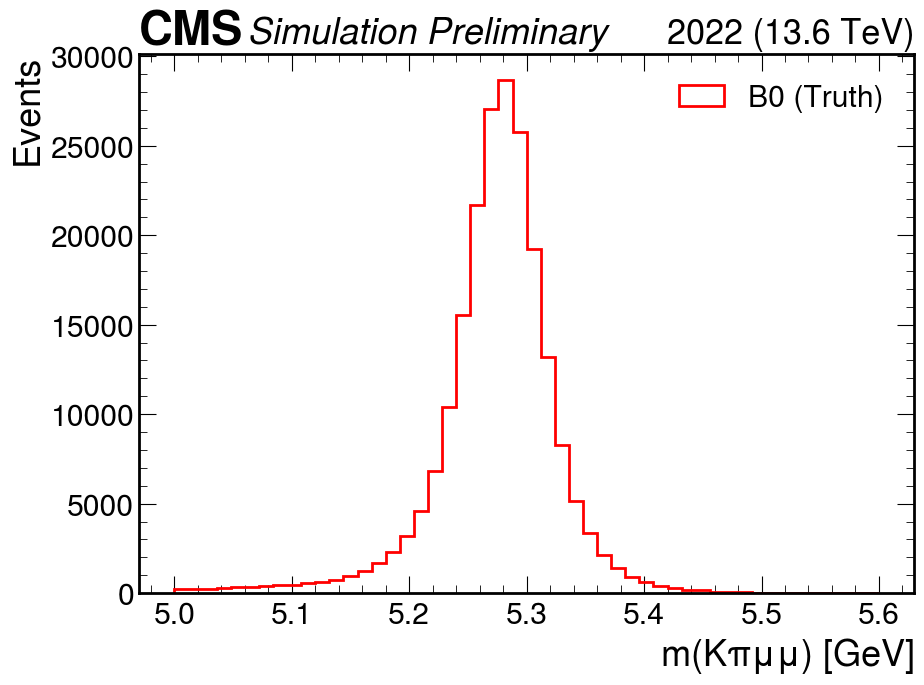

In [22]:
plt.figure(figsize=(10, 7))
data = ak.to_numpy(ak.flatten(clean_mass, axis=None))

plt.hist(data, bins=50, histtype='step', range=(5.0, 5.6), lw=2, color='red', label='B0 (Truth)')
plt.xlabel(r"$m(K\pi\mu\mu)$ [GeV]") 
plt.ylabel("Events")
plt.legend()
hep.cms.label("Preliminary", data=False, year="2022", com=13.6) 
plt.show()

In [24]:
# Print com a Bisavó para ver o B0 aparecendo nos casos de FSR
indices_validos = ak.fill_none(truth_match_final, False)
filt_mom = mom_mu1_pdg[indices_validos]
filt_gmom = gmom_mu1_pdg[indices_validos]
filt_ggmom = ggmom_mu1_pdg[indices_validos]

count = 0
print(f"{'Evento':<8} | {'Mãe (Fóton?)':<12} | {'Avó (Psi(2s)?)':<12} | {'Bisavó (B0?)':<12}")
print("-" * 55)
for i in range(len(filt_mom)):
    for j in range(len(filt_mom[i])):
        if count < 10:
            print(f"{i:<8} | {filt_mom[i][j]:<12} | {filt_gmom[i][j]:<12} | {filt_ggmom[i][j]:<12}")
            count += 1

Evento   | Mãe (Fóton?) | Avó (Psi(2s)?) | Bisavó (B0?)
-------------------------------------------------------
0        | 22           | 100443       | 511         
1        | 22           | 100443       | 511         
4        | 22           | 100443       | 511         
5        | 22           | 100443       | 511         
6        | 22           | 100443       | 511         
7        | 22           | 100443       | 511         
9        | 22           | 100443       | 511         
16       | 22           | 100443       | 511         
17       | 22           | 100443       | 511         
22       | 22           | 100443       | 511         
